In [1]:
import fig02
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

from drift_diffusion.model import DriftDiffusionModel
from drift_diffusion.sim import sample_from_ssm

# notebook defaults
plt.rcParams.update({"font.size": 14, "font.family": "Helvetica", "savefig.transparent": True})

In [2]:
# simulation setting
params = {"a": 0.63, "t0": 0.435, "v": 2.23, "z": 0.008}  # Matzke 2009, Table 3 (Mean)
params_s = {"t0": 0.183, "v": 1.33, "z": 0.37}
param_names = list(params.keys())
cov_names = [f"{i},{j}" for i in param_names for j in param_names]

In [3]:
# calc pseudo-true params
n_samples, n_repeats = 10_000, 1
X = pd.DataFrame({"intercept": np.ones(n_samples)})
t0_iid, v_iid, z_iid = fig02.iid_params(n_samples, params, params_s)
y = sample_from_ssm(
    a=params["a"], t0=t0_iid, v=v_iid, z=z_iid, n_samples=n_samples, n_repeats=n_repeats, random_state=0
)
ddm = DriftDiffusionModel()
ddm.fit(X, y)
pseudotrue_params = dict(zip(["a", "t0", "v", "z"], ddm.params_))

In [4]:
refit = False  # !! set to True to refit simulations !!

if refit:
    n_samples, n_repeats = 1000, 900
    t0_iid, v_iid, z_iid = fig02.iid_params(n_samples, params, params_s)
    X = pd.DataFrame({"intercept": np.ones(n_samples)})
    ys = sample_from_ssm(
        a=params["a"], t0=t0_iid, v=v_iid, z=z_iid, n_samples=n_samples, n_repeats=n_repeats, random_state=0
    )

    # fit ddm
    ddm = DriftDiffusionModel(cov_estimator="all")

    @delayed
    def run_simulation(rep):
        ddm.fit(X, ys[:, rep])
        covs_ = [
            {"estimator": k, **{cov_names[i]: val for i, val in enumerate(fig02.cov_to_corr(v).flatten())}}
            for k, v in ddm.covariance_.items()
        ]
        return ddm.params_, covs_

    with Parallel(n_jobs=-4) as parallel:
        results = parallel(run_simulation(rep) for rep in tqdm(range(n_repeats)))
        params_, covs_ = zip(*results)
        params_df = pd.DataFrame(params_, columns=param_names)
        covs_df = pd.DataFrame([row for c in covs_ for row in c])

else:
    params_df = pd.read_csv("results/sim-iid-params.csv")
    covs_df = pd.read_csv("results/sim-iid-covs.csv")

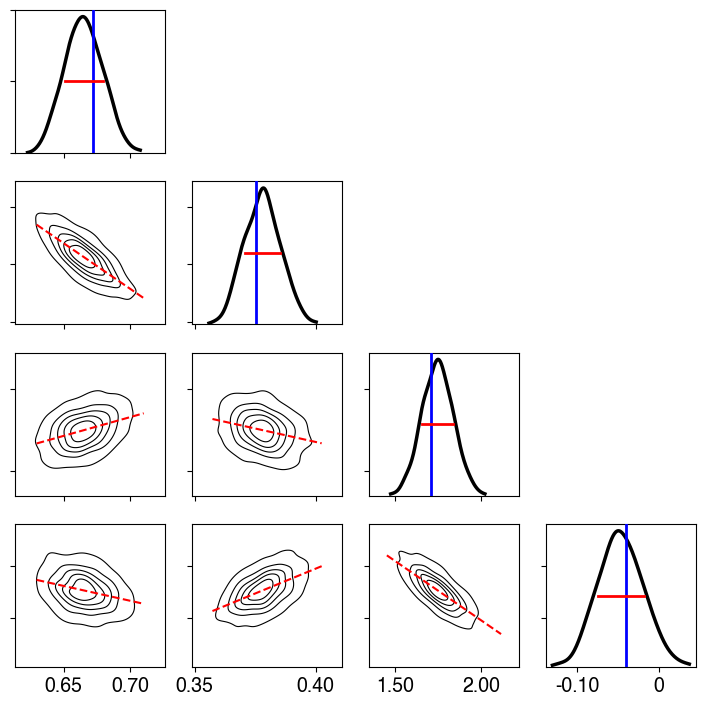

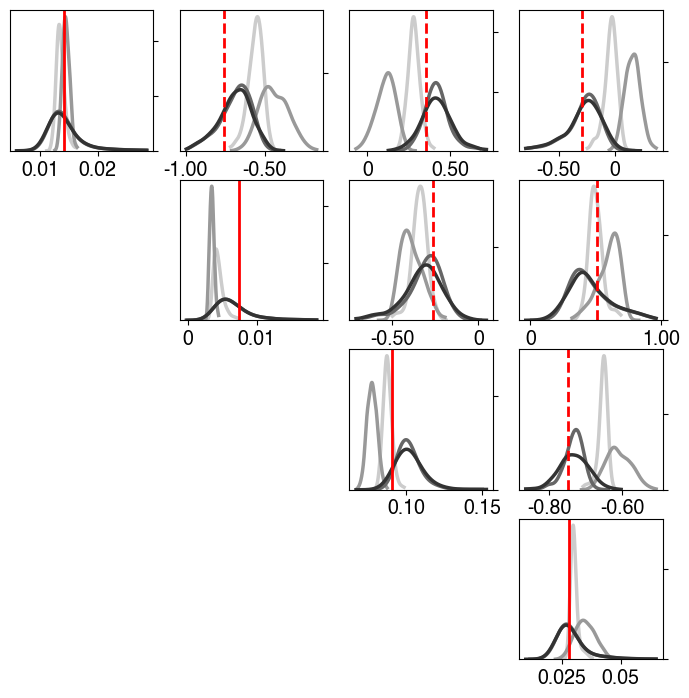

In [5]:
fig = fig02.plot_parameter_distributions(params_df, pseudotrue_params)
fig.savefig("params.pdf")
fig = fig02.plot_covariance_distributions(covs_df, params_df)
fig.savefig("covs.pdf")